# 💻 Hands-On Lab Part 3 — Vegetation Indices and Empirical Regression (45 Minutes)

In this section, we will explore a broader range of remote sensing indicators. You will begin by researching alternative vegetation indices and implementing one of your choice to strengthen your coding/reading skills. Afterward, we will conduct an algorithmic cross-validation: you will calculate NDVI and NDWI time series, apply empirical regression models to estimate the Vegetation Water Content (VWC) of a sample wheat field, and evaluate how these satellite-derived values compare to real, in-situ ground-truth data.

---

## 🔍 Step 1: Researching Alternative Indices

Explore the [ClearSky Vision Sentinel-2 Indices Cheatsheet](https://clearsky.vision/knowledge/sentinel2-indices-cheatsheet) to find an index that interests you or fits your study area's crop characteristics.

---

## 🧪 Step 2: Student Challenge — Calculate Your Chosen Index

Using the mathematical formulation of your chosen index from the reference sheet, write the missing array algebra inside the Python execution cell below. 

> ⚠️ **Critical Spatial Alignment Rule:** Remember that Sentinel-2 bands do not all share the same native pixel size. If your selected index mixes 10-meter bands (such as `B02`, `B04`, `B08`) with 20-meter bands (such as `B11` or `B12`), you **must** implement the `.rio.reproject_match()` protocol you mastered in Part 2 to align the matrix dimensions!

* **Action Required:** Complete the index calculation line in the code snippet below, generate the raster layer, and plot your spatial results.

In [1]:
# Uncomment the line below if you need to install the dependencies in your environment
# !pip install pystac-client pystac shapely planetary-computer requests matplotlib

import json
from pystac_client import Client
import planetary_computer as pc
from shapely.geometry import shape, mapping
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
import rioxarray

print("📦 Libraries imported successfully! Ready to connect to the datacube.")


Bad key keymap.all_axes in file matplotlibrc, line 398 ('keymap.all_axes : a                 # enable all axes')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.9/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


📦 Libraries imported successfully! Ready to connect to the datacube.


In [2]:
# Define a bounding box around a high-production agricultural region
# Format: [min_longitude, min_latitude, max_longitude, max_latitude]
aoi_bbox = [13.15, 52.35, 13.18, 52.38] 

# Convert the bounding box into a standard GeoJSON geometry dictionary
aoi_geometry = {
    "type": "Polygon",
    "coordinates": [[
        [aoi_bbox[0], aoi_bbox[1]],
        [aoi_bbox[0], aoi_bbox[3]],
        [aoi_bbox[2], aoi_bbox[3]],
        [aoi_bbox[2], aoi_bbox[1]],
        [aoi_bbox[0], aoi_bbox[1]]
    ]]
}

print("Farm boundary geometry locked in. Ready to query.")


# Connect to the global cloud catalog endpoint
catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=pc.sign_inplace,
)

# Execute the programmatic search query
search = catalog.search(
    collections=["sentinel-2-l2a"],
    intersects=aoi_geometry,
    datetime="2017-04-01/2017-07-10",
    query={"eo:cloud_cover": {"lt": 10}} # Filter: less than 10% cloud cover
)

# Fetch all matching items found in the cloud registry
items = list(search.get_items())
print(f"📡 API Query Complete! Found {len(items)} cloud-free satellite scenes matching your criteria.")

s2_items = [pc.sign(item) for item in search.get_items()]
cropping_poly = shape(aoi_geometry)

print(f"📈 Analytics engine armed. Ready to process {len(s2_items)} multi-spectral scenes.")

Farm boundary geometry locked in. Ready to query.


/usr/local/lib/python3.10/site-packages/pystac_client/item_search.py:925: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(


📡 API Query Complete! Found 2 cloud-free satellite scenes matching your criteria.
📈 Analytics engine armed. Ready to process 2 multi-spectral scenes.


In [3]:
def process_student_challenge_index(index_frame):
    if not s2_items:
        print("❌ No imagery layers found.")
        return
        
    current_item = s2_items[index_frame]
    
    try:
        # 📥 1. STREAM AND CLIP YOUR SPECIFIC BANDS
        # (Example below sets up basic bands; modify according to your chosen index)
        url_b08 = current_item.assets["B08"].href # NIR
        raster_b08 = rioxarray.open_rasterio(url_b08)
        clip_b08 = raster_b08.rio.clip([cropping_poly], crs="EPSG:4326", from_disk=True)
        nir = clip_nir = clip_b08.data[0].astype(float)
        
        url_b04 = current_item.assets["B04"].href # Red
        raster_b04 = rioxarray.open_rasterio(url_b04)
        clip_b04 = raster_b04.rio.clip([cropping_poly], crs="EPSG:4326", from_disk=True)
        red = clip_b04.data[0].astype(float)
        
        # NOTE: If you use a 20m band (like B11 for NDWI), uncomment and use this alignment block:
        # url_b11 = current_item.assets["B11"].href
        # raster_b11 = rioxarray.open_rasterio(url_b11)
        # clip_b11 = raster_b11.rio.clip([cropping_poly], crs="EPSG:4326", from_disk=True).rio.reproject_match(clip_b08)
        # swir = clip_b11.data[0].astype(float)

        # 🧮 2. WRITE YOUR SPECIFIC MATRIX ARITHMETIC HERE
        # ----------------------------------------------------
        # STUDENT TODO EXAMPLES:       
        calculated_index = (nir - red) / (nir + red) # Placeholder default (NDVI)
        # ----------------------------------------------------
        
        # Render the custom output map
        plt.figure(figsize=(10, 8))
        img_plot = plt.imshow(calculated_index, cmap="viridis")
        plt.colorbar(img_plot, label="Custom Index Value")
        plt.title(f"🚀 Custom Research Index Assessment\n📅 Date: {str(current_item.datetime)[:16]}", fontsize=12, fontweight='bold')
        plt.axis("off")
        plt.show()
        
    except Exception as e:
        print(f"💥 Compilation error in your index math: {e}")

# Slider to scrub your custom calculation over time
if s2_items:
    widgets.interact(process_student_challenge_index, index_frame=widgets.IntSlider(min=0, max=len(s2_items)-1, step=1, value=0, description='Timeline:'))

interactive(children=(IntSlider(value=0, description='Timeline:', max=1), Output()), _dom_classes=('widget-int…

---

## 📈 Step 3: Automated Multi-Temporal Time Series Tracking via Shapefile

In a commercial digital agronomy workflow, nobody checks fields one satellite image at a time. Instead, we use vector files—like a **Shapefile (`.shp`)** or **GeoJSON** representing exact farm parcel boundaries—to automatically extract, calculate, and graph crop trends over an entire season.

In this step, we will use a local field boundary shapefile to calculate and track three vital agronomic metrics across your entire timeline:
1. **NDVI**
2. **NDWI (1610nm - Band 11)** 
3. **NDWI (2190nm - Band 12)**

Because we are mixing $10\text{m}$ and $20\text{m}$ bands, the engine will automatically reproject and match the spatial grids to ensure perfect mathematical alignment.

* **Action Required:** Update the file path to point to your field boundary shapefile, then run the cell to generate the seasonal trend graph.
* **Action Required:** Read the following article about empirial regression to extract VWC from different optical indices (https://www.researchgate.net/publication/274065380_Optical_Sensing_of_Vegetation_Water_Content_A_Synthesis_Study) - empirical equations of Table IV are used below!

---

### 📈 Let's first try to just retrive one pixel


📦 Loading shapefile and computing center pixel location...
✅ Centroid calculated in native projection: EPSG:32632

🌍 Connecting to Planetary Computer STAC Catalog...
🔍 Querying available overlapping Sentinel-2 scenes...
🎯 Target Tile ID Selected: 32UPU
📡 Found 20 scenes. Beginning single-pixel extraction pipeline...
 🟢 Sampled center pixel successfully: 2017-01-27
 🟢 Sampled center pixel successfully: 2017-02-16
 🟢 Sampled center pixel successfully: 2017-03-28
 🟢 Sampled center pixel successfully: 2017-04-24
 🟢 Sampled center pixel successfully: 2017-05-17
 🟢 Sampled center pixel successfully: 2017-05-27
 🟢 Sampled center pixel successfully: 2017-06-03
 🟢 Sampled center pixel successfully: 2017-06-13
 🟢 Sampled center pixel successfully: 2017-06-26
 🟢 Sampled center pixel successfully: 2017-07-06
 🟢 Sampled center pixel successfully: 2017-07-08
 🟢 Sampled center pixel successfully: 2017-07-21
 🟢 Sampled center pixel successfully: 2017-08-05
 🟢 Sampled center pixel successfully: 2017-08

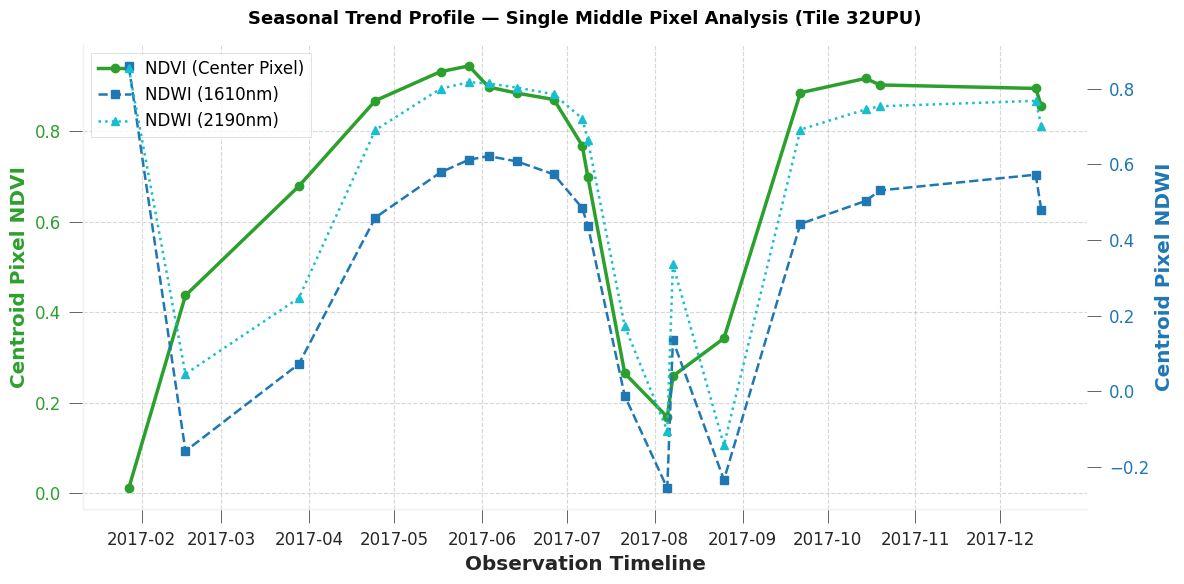

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rioxarray
from pystac_client import Client
import planetary_computer
from datetime import datetime
import warnings

# Mute minor warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# ==========================================================
# 1. CONFIGURATION & CENTROID GENERATION
# ==========================================================
shapefile_path = "SF_data/MNI_2017.shp" 

print("📦 Loading shapefile and computing center pixel location...")
all_fields_gdf = gpd.read_file(shapefile_path)

# Calculate the precise center point (Centroid) of the shapefile
centroid_gdf = all_fields_gdf.copy()
centroid_gdf['geometry'] = centroid_gdf.geometry.centroid

print(f"✅ Centroid calculated in native projection: {centroid_gdf.crs}")

# ==========================================================
# 2. REFRESH STAC API CATALOG SEARCH
# ==========================================================
print("\n🌍 Connecting to Planetary Computer STAC Catalog...")
catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

# Convert center point to EPSG:4326 degrees for STAC lookup
centroid_4326 = centroid_gdf.to_crs("EPSG:4326")
search_geometry = centroid_4326.geometry.values[0].__geo_interface__

print("🔍 Querying available overlapping Sentinel-2 scenes...")
search = catalog.search(
    collections=["sentinel-2-l2a"],
    intersects=search_geometry,
    datetime="2017-01-01/2017-12-31", 
    query={"eo:cloud_cover": {"lt": 20}}
)

raw_items = search.item_collection()

# Isolate primary tile to eliminate duplicates
first_item = raw_items[0]
primary_tile_id = first_item.properties.get("s2:mgrs_tile") or first_item.properties.get("grid:code")
if primary_tile_id is None:
    import re
    match = re.search(r'_T([0-9]{2}[A-Z]{3})_', first_item.id)
    primary_tile_id = match.group(1) if match else None

s2_items = [item for item in raw_items if primary_tile_id in item.id or item.properties.get("s2:mgrs_tile") == primary_tile_id]

print(f"🎯 Target Tile ID Selected: {primary_tile_id}")
print(f"📡 Found {len(s2_items)} scenes. Beginning single-pixel extraction pipeline...")

# ==========================================================
# 3. CENTROID PIXEL SAMPLING LOOP
# ==========================================================
# Variables synchronized for the CSV validation notebook cells
satellite_dates = []
ndvi_values = []
ndwi_1610_values = []
ndwi_2190_values = []

for item in sorted(s2_items, key=lambda x: x.datetime):
    scene_date = "Unknown Date"
    try:
        scene_date = item.datetime if isinstance(item.datetime, datetime) else datetime.fromisoformat(str(item.datetime)[:19])
        
        url_b08 = item.assets["B08"].href   # NIR
        url_b04 = item.assets["B04"].href   # Red
        url_b8a = item.assets["B8A"].href   # Narrow NIR
        url_b11 = item.assets["B11"].href   # SWIR-1 (1610nm)
        url_b12 = item.assets["B12"].href   # SWIR-2 (2190nm)
        
        # 1. Open the anchor band to read the raster projection setup
        raster_b08 = rioxarray.open_rasterio(url_b08)
        current_raster_crs = raster_b08.rio.crs
        
        # 2. Transform our single centroid point to match the current image projection
        point_projected = centroid_gdf.to_crs(current_raster_crs).geometry.values[0]
        p_x, p_y = point_projected.x, point_projected.y
        
        # 3. Sample the single closest pixel coordinate directly (Zero data streaming overhead)
        b08 = float(raster_b08.sel(x=p_x, y=p_y, method="nearest").values[0])
        
        raster_b04 = rioxarray.open_rasterio(url_b04)
        b04 = float(raster_b04.sel(x=p_x, y=p_y, method="nearest").values[0])
        
        raster_b8a = rioxarray.open_rasterio(url_b8a)
        b8a = float(raster_b8a.sel(x=p_x, y=p_y, method="nearest").values[0])
        
        raster_b11 = rioxarray.open_rasterio(url_b11)
        b11 = float(raster_b11.sel(x=p_x, y=p_y, method="nearest").values[0])
        
        raster_b12 = rioxarray.open_rasterio(url_b12)
        b12 = float(raster_b12.sel(x=p_x, y=p_y, method="nearest").values[0])
        
        # Check if the sampled center point lands on a nodata fill value
        if b08 == raster_b08.rio.nodata or np.isnan(b08):
            continue
        
        # 🧮 Compute single-point indices equations
        ndvi = (b08 - b04) / (b08 + b04)
        ndwi_1610 = (b08 - b11) / (b08 + b11)
        ndwi_2190 = (b08 - b12) / (b08 + b12)
        
        satellite_dates.append(scene_date)
        ndvi_values.append(ndvi)
        ndwi_1610_values.append(ndwi_1610)
        ndwi_2190_values.append(ndwi_2190)
        
        print(f" 🟢 Sampled center pixel successfully: {scene_date.strftime('%Y-%m-%d')}")
        
    except Exception as e:
        print(f" ⏭️ Skipping date {scene_date.strftime('%Y-%m-%d')} due to processing drop: {e}")
        continue

# ==========================================================
# 4. PLOT GENERATION
# ==========================================================
print("\n局 Generating final single-pixel timeline metrics...")
if len(satellite_dates) > 0:
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    color1 = 'tab:green'
    ax1.set_xlabel('Observation Timeline', fontweight='bold')
    ax1.set_ylabel('Centroid Pixel NDVI', color=color1, fontweight='bold')
    ax1.plot(satellite_dates, ndvi_values, color=color1, marker='o', linewidth=2.5, label='NDVI (Center Pixel)')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    ax2 = ax1.twinx()  
    color2 = 'tab:blue'
    color3 = 'tab:cyan'
    ax2.set_ylabel('Centroid Pixel NDWI', color=color2, fontweight='bold')
    ax2.plot(satellite_dates, ndwi_1610_values, color=color2, marker='s', linestyle='--', linewidth=1.8, label='NDWI (1610nm)')
    ax2.plot(satellite_dates, ndwi_2190_values, color=color3, marker='^', linestyle=':', linewidth=1.8, label='NDWI (2190nm)')
    ax2.tick_params(axis='y', labelcolor=color2)
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    plt.title(f'Seasonal Trend Profile — Single Middle Pixel Analysis (Tile {primary_tile_id})', fontsize=13, fontweight='bold', pad=15)
    fig.tight_layout()
    plt.show()
else:
    print("❌ No valid time series entries found.")

---

### 📈 Let's try to use the entire field as specified by the shapefile

- What problems do arrise?

📦 Loading vector shapefile polygon...
✅ Loaded shapefile natively in EPSG:32632

🌍 Connecting to Planetary Computer STAC Catalog...
🔍 Querying available overlapping Sentinel-2 scenes...
🎯 Target Tile ID Selected: 32UPU
📡 Found 20 scenes. Beginning full polygon extraction pipeline...

⏳ Commencing pixel clipping loop across timeline...
 🟢 Processed polygon scene successfully: 2017-01-27
 🟢 Processed polygon scene successfully: 2017-02-16
 🟢 Processed polygon scene successfully: 2017-03-28
 🟢 Processed polygon scene successfully: 2017-04-24
 🟢 Processed polygon scene successfully: 2017-05-17
 🟢 Processed polygon scene successfully: 2017-05-27
 🟢 Processed polygon scene successfully: 2017-06-03
 🟢 Processed polygon scene successfully: 2017-06-13
 🟢 Processed polygon scene successfully: 2017-06-26
 🟢 Processed polygon scene successfully: 2017-07-06
 🟢 Processed polygon scene successfully: 2017-07-08
 🟢 Processed polygon scene successfully: 2017-07-21
 🟢 Processed polygon scene successfully

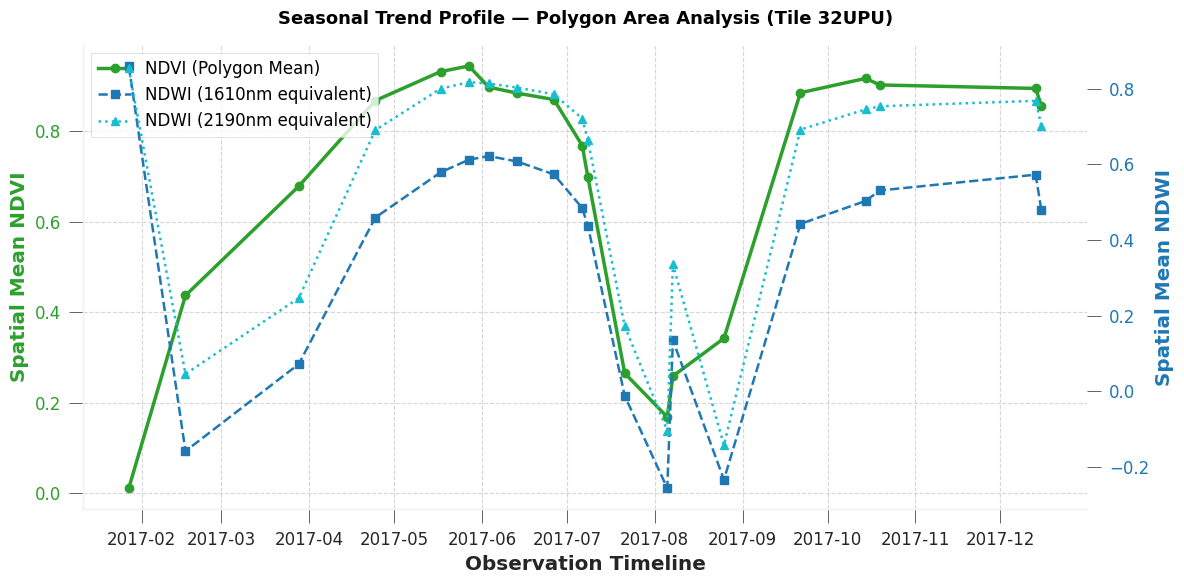

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rioxarray
from rioxarray.exceptions import NoDataInBounds
from pystac_client import Client
import planetary_computer
from datetime import datetime
import warnings

# Mute minor warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# ==========================================================
# 1. CONFIGURATION & POLYGON SETUP
# ==========================================================
shapefile_path = "SF_data/MNI_2017.shp" 

print("📦 Loading vector shapefile polygon...")
all_fields_gdf = gpd.read_file(shapefile_path)
native_crs = all_fields_gdf.crs
print(f"✅ Loaded shapefile natively in {native_crs}")

# ==========================================================
# 2. REFRESH STAC API CATALOG SEARCH
# ==========================================================
print("\n🌍 Connecting to Planetary Computer STAC Catalog...")
catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

# Convert polygon to EPSG:4326 degrees for STAC area lookups
fields_4326 = all_fields_gdf.to_crs("EPSG:4326")
search_geometry = fields_4326.geometry.values[0].__geo_interface__

print("🔍 Querying available overlapping Sentinel-2 scenes...")
search = catalog.search(
    collections=["sentinel-2-l2a"],
    intersects=search_geometry,
    datetime="2017-01-01/2017-12-31", 
    query={"eo:cloud_cover": {"lt": 20}}
)

raw_items = search.item_collection()

# Isolate primary tile to eliminate duplicate border scene records
first_item = raw_items[0]
primary_tile_id = first_item.properties.get("s2:mgrs_tile") or first_item.properties.get("grid:code")
if primary_tile_id is None:
    import re
    match = re.search(r'_T([0-9]{2}[A-Z]{3})_', first_item.id)
    primary_tile_id = match.group(1) if match else None

s2_items = [item for item in raw_items if primary_tile_id in item.id or item.properties.get("s2:mgrs_tile") == primary_tile_id]

print(f"🎯 Target Tile ID Selected: {primary_tile_id}")
print(f"📡 Found {len(s2_items)} scenes. Beginning full polygon extraction pipeline...")

# ==========================================================
# 3. POLYGON GEOMETRY SPATIAL CLIPPING LOOP
# ==========================================================
# Updated tracking variable names to prevent downstream cell issues
satellite_dates_field = []
ndvi_values_field = []
ndwi_1610_values_field = []
ndwi_2190_values_field = []

print("\n⏳ Commencing pixel clipping loop across timeline...")

for item in sorted(s2_items, key=lambda x: x.datetime):
    scene_date = "Unknown Date"
    try:
        scene_date = item.datetime if isinstance(item.datetime, datetime) else datetime.fromisoformat(str(item.datetime)[:19])
        
        url_b08 = item.assets["B08"].href   # NIR (10m)
        url_b04 = item.assets["B04"].href   # Red (10m)
        url_b8a = item.assets["B8A"].href   # Narrow NIR (20m)
        url_b11 = item.assets["B11"].href   # SWIR-1 (1610nm)
        url_b12 = item.assets["B12"].href   # SWIR-2 (2190nm)
        
        # 1. Open baseline anchor band to extract its grid UTM CRS
        raster_b08 = rioxarray.open_rasterio(url_b08)
        current_raster_crs = raster_b08.rio.crs
        
        # 🔄 DYNAMIC REPROJECTION: Adapt polygon to match current image's specific UTM zone
        field_geom_projected = all_fields_gdf.to_crs(current_raster_crs).geometry.values
        
        # 2. Extract entire masked polygon arrays from cloud files
        clip_b08 = raster_b08.rio.clip(field_geom_projected, all_touched=True, from_disk=False)
        b08 = clip_b08.data[0].astype(float)
        
        raster_b04 = rioxarray.open_rasterio(url_b04)
        clip_b04 = raster_b04.rio.clip(field_geom_projected, all_touched=True, from_disk=False)
        b04 = clip_b04.data[0].astype(float)
        
        # 20-meter resolution bands reprojected to match our 10-meter anchor mask matrix grid
        raster_b8a = rioxarray.open_rasterio(url_b8a)
        clip_b8a = raster_b8a.rio.clip(field_geom_projected, all_touched=True, from_disk=False).rio.reproject_match(clip_b08)
        b8a = clip_b8a.data[0].astype(float)
        
        raster_b11 = rioxarray.open_rasterio(url_b11)
        clip_b11 = raster_b11.rio.clip(field_geom_projected, all_touched=True, from_disk=False).rio.reproject_match(clip_b08)
        b11 = clip_b11.data[0].astype(float)
        
        raster_b12 = rioxarray.open_rasterio(url_b12)
        clip_b12 = raster_b12.rio.clip(field_geom_projected, all_touched=True, from_disk=False).rio.reproject_match(clip_b08)
        b12 = clip_b12.data[0].astype(float)
        
        # Strip out no-data background padding signatures safely
        b08[b08 == raster_b08.rio.nodata] = np.nan
        
        # 🧮 Compute index matrices across polygon layout (Added small epsilon to protect division)
        ndvi_array = (b08 - b04) / (b08 + b04)
        ndwi_1610_array = (b08 - b11) / (b08 + b11)
        ndwi_2190_array = (b08 - b12) / (b08 + b12)
        
        # Calculate spatial means exclusively over your field space geometry
        satellite_dates_field.append(scene_date)
        ndvi_values_field.append(np.nanmean(ndvi_array))
        ndwi_1610_values_field.append(np.nanmean(ndwi_1610_array))
        ndwi_2190_values_field.append(np.nanmean(ndwi_2190_array))
        
        print(f" 🟢 Processed polygon scene successfully: {scene_date.strftime('%Y-%m-%d')}")
        
    except (NoDataInBounds, ValueError):
        print(f" ⏭️ Skipping date {scene_date.strftime('%Y-%m-%d')}: Sits on border frame edge.")
        continue
    except Exception as e:
        print(f" ⏭️ Skipping date {scene_date.strftime('%Y-%m-%d')} due to processing drop: {e}")
        continue

# ==========================================================
# 4. PLOT GENERATION
# ==========================================================
print("\n📊 Generating polygon profile timeline metrics...")
if len(satellite_dates) > 0:
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    color1 = 'tab:green'
    ax1.set_xlabel('Observation Timeline', fontweight='bold')
    ax1.set_ylabel('Spatial Mean NDVI', color=color1, fontweight='bold')
    ax1.plot(satellite_dates, ndvi_values, color=color1, marker='o', linewidth=2.5, label='NDVI (Polygon Mean)')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    ax2 = ax1.twinx()  
    color2 = 'tab:blue'
    color3 = 'tab:cyan'
    ax2.set_ylabel('Spatial Mean NDWI', color=color2, fontweight='bold')
    ax2.plot(satellite_dates, ndwi_1610_values, color=color2, marker='s', linestyle='--', linewidth=1.8, label='NDWI (1610nm equivalent)')
    ax2.plot(satellite_dates, ndwi_2190_values, color=color3, marker='^', linestyle=':', linewidth=1.8, label='NDWI (2190nm equivalent)')
    ax2.tick_params(axis='y', labelcolor=color2)
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    plt.title(f'Seasonal Trend Profile — Polygon Area Analysis (Tile {primary_tile_id})', fontsize=13, fontweight='bold', pad=15)
    fig.tight_layout()
    plt.show()
else:
    print("❌ No valid time series entries found.")

---

### 📈 Let's compare the satellite data with in-situ data

📋 Loading VWC validation dataset...
✅ Loaded 17 validation entries from columns: 'date' and 'VWC kg/m2'

🧮 Calculating remote sensing VWC from active memory arrays...
✅ Index mathematical transformations complete.

📊 Plotting final cross-validation metrics...


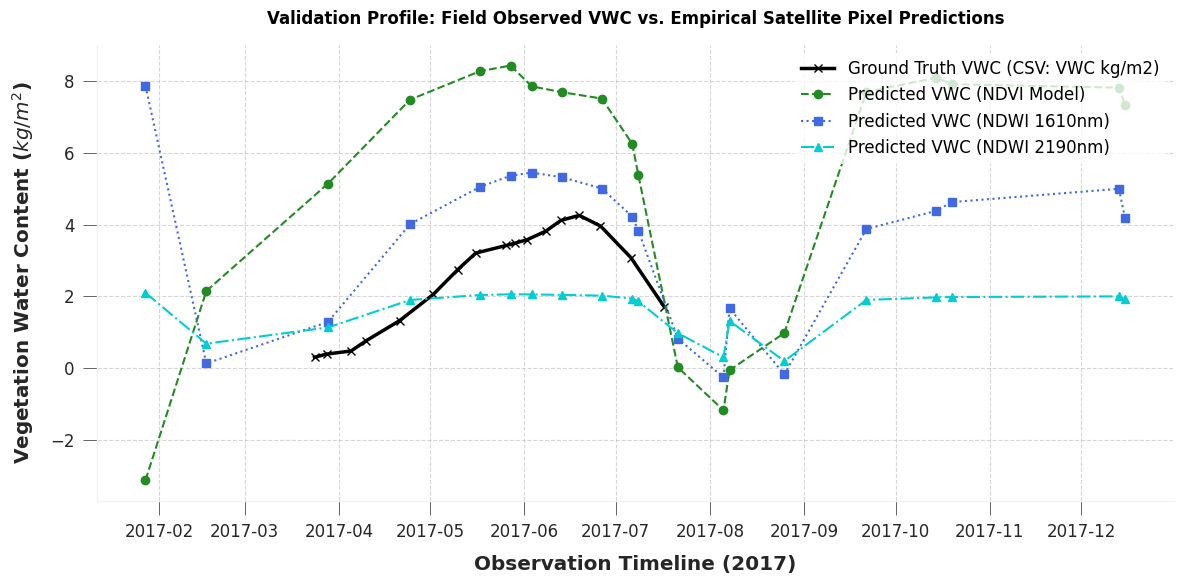

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Mute minor datetime conversion or runtime warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# ==========================================================
# 1. LOAD AND PARSE THE NEW CSV STRUCTURE
# ==========================================================
csv_path = "SF_data/508.csv"  # Points to the file in the workspace directory
print("📋 Loading VWC validation dataset...")

# Read the CSV with its semicolon separator
df_csv = pd.read_csv(csv_path, sep=';', low_memory=False)

# Clean whitespaces around header titles to avoid key errors
df_csv.columns = [str(col).strip() for col in df_csv.columns]

# Parse dates and drop rows containing invalid/missing values
df_csv['date'] = pd.to_datetime(df_csv['date'], errors='coerce')
df_csv = df_csv.dropna(subset=['date'])

# Force cast the new ground truth VWC column to standard floats
df_csv['VWC_observed'] = pd.to_numeric(df_csv['VWC kg/m2'], errors='coerce')
df_csv = df_csv.dropna(subset=['VWC_observed']).sort_values('date')

# Extract vectors for plotting
csv_dates = df_csv['date'].tolist()
vwc_observed = df_csv['VWC_observed'].values

print(f"✅ Loaded {len(csv_dates)} validation entries from columns: 'date' and 'VWC kg/m2'")

# ==========================================================
# 2. ALLAHMORADI VWC EQUATION PROCESSING FOR CEREAL
# ==========================================================
print("\n🧮 Calculating remote sensing VWC from active memory arrays...")

# Using the precise variable names generated in your single-pixel cell
sat_dates = np.array(satellite_dates)
ndvi_arr = np.array(ndvi_values, dtype=float)
ndwi_1610_arr = np.array(ndwi_1610_values, dtype=float)
ndwi_2190_arr = np.array(ndwi_2190_values, dtype=float)

# Variant A: Using NDWI (1610nm equivalent / Band 8 vs Band 11)
vwc_pred_ndwi_1610 = 3.25 * ndwi_1610_arr**2 + 5.31 * ndwi_1610_arr + 0.89

# Variant B: Using NDWI (2190nm equivalent / Band 8 vs Band 12)
vwc_pred_ndwi_2190 = -0.82 * ndwi_2190_arr**2 + 2.49 * ndwi_2190_arr + 0.57

# Variant C: Using the Exponential NDVI relationship 
vwc_pred_ndvi = 12.38 * ndvi_arr - 3.26

print("✅ Index mathematical transformations complete.")

# ==========================================================
# 3. GENERATE COMPARATIVE TIMELINE CHART
# ==========================================================
print("\n📊 Plotting final cross-validation metrics...")
fig, ax = plt.subplots(figsize=(12, 6))

# 📉 Curve 1: The true field validation measurements from the CSV file
ax.plot(csv_dates, vwc_observed, color='black', linestyle='-', linewidth=2.5, 
        marker='x', label='Ground Truth VWC (CSV: VWC kg/m2)')

# 📡 Curves 2, 3 & 4: Predictions computed via your previous cloud-satellite loop
if len(sat_dates) > 0:
    ax.plot(sat_dates, vwc_pred_ndvi, color='forestgreen', marker='o', 
            linestyle='--', linewidth=1.5, label='Predicted VWC (NDVI Model)')
    
    ax.plot(sat_dates, vwc_pred_ndwi_1610, color='royalblue', marker='s', 
            linestyle=':', linewidth=1.5, label='Predicted VWC (NDWI 1610nm)')
    
    ax.plot(sat_dates, vwc_pred_ndwi_2190, color='darkturquoise', marker='^', 
            linestyle='-.', linewidth=1.5, label='Predicted VWC (NDWI 2190nm)')

# Formatting details
ax.set_xlabel('Observation Timeline (2017)', fontweight='bold', labelpad=10)
ax.set_ylabel('Vegetation Water Content ($kg/m^2$)', fontweight='bold', labelpad=10)
ax.set_title('Validation Profile: Field Observed VWC vs. Empirical Satellite Pixel Predictions', 
             fontsize=12, fontweight='bold', pad=15)

ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

fig.tight_layout()
plt.show()

---

## 🛠️ Student Checkpoint & Lab Challenge

1. **Share Your Findings:** Present your chosen index from Step 1 and Step 2 to your colleagues, explaining why you selected it and how it visualizes crop characteristics.
2. **Evaluate Empirical Models:** Discuss the advantages and disadvantages of empirical regression models with your team. Use your plot comparing the satellite-retrieved VWC with the in-situ data as a starting point for your analysis.
3. **Indices vs. Radiative Transfer Models (RTMs):** In the next section, we will transition from simple empirical indices to physically-based radiative transfer models. Compile a comparative list detailing the pros and cons of both approaches. Based on your list, under which specific field or environmental conditions would you choose one approach over the other?

This question requires evaluating the trade-offs between a statistical/empirical approach (e.g., NDVI/NDWI curve fitting) and a physically-based approach (e.g., PROSAIL radiative transfer modeling).

| Feature / Criteria | Empirical Index Approaches (e.g., NDVI, NDWI) | Radiative Transfer Models (RTMs; e.g., PROSAIL) |
| :--- | :--- | :--- |
| **Scientific Basis** |  |  |
| **Transferability** |  |  |
| **Input Overhead** |  |  |
| **Computational Demand**| |  |
| **Forecasting & Predictive Capability** |  |  |